In [6]:
import pandas as pd
import seaborn as sns
import itertools
from typing import cast

import math
import numpy as np

from matplotlib import pyplot as plt
from matplotlib.axes import Axes
import matplotlib.colors as mcolors
from matplotlib_inline.backend_inline import set_matplotlib_formats
%matplotlib inline
set_matplotlib_formats('svg')

df = pd.read_csv('malware_dacrank1_xhour.csv', index_col=0)
df['hour'] = df['hour'].astype(int)
df

,day,hour,dac_family,qr,r,nx,dn_rank_1,wl_rank_le4,u,u_wl_rank_le4,u_dn_rank_1
0,0,10,virut,23,12,0,23,0,1,0,1
1,0,11,virut,1,0,0,1,0,1,0,1
2,0,18,healthy,1664600,749380,51621,1620842,532254,54218,4325,51601
3,0,9,modpack,31,15,0,31,0,1,0,1
4,0,9,necurs,24470,6202,11349,24470,0,1996,0,1996
...,...,...,...,...,...,...,...,...,...,...,...
94,9,6,healthy,715606,361438,20318,701316,165543,22679,2453,21831
95,9,4,modpack,12,6,0,12,0,1,0,1
96,9,18,pitou,1088,497,423,1088,0,20,0,20
97,9,13,modpack,98,45,0,98,0,2,0,2


In [7]:

day = list(range(10))
hours = list(range(24))
dac_families = df.dac_family.drop_duplicates()
cols = ['qr', 'r', 'nx', 'dn_rank_1', 'wl_rank_le4',
       'u', 'u_wl_rank_le4', 'u_dn_rank_1']

values = []
for a, b, c in itertools.product(day, hours, dac_families):
    values.append([a,b,c] + [0 for _ in range(len(cols))])

df0 = pd.DataFrame(data=values, columns=df.columns)

# pd.merge(df, right=df0, left_on=['day','dac_family'], right_on=['day','dac_family'], how='left')
DF = pd.concat([df, df0]).drop_duplicates(subset=['day', 'hour', 'dac_family']).sort_values(by=['day', 'hour', 'dac_family']).reset_index(drop=True)

DF = DF[DF.hour < 24]

DF['hourx'] = DF['day'] * 24 + DF['hour']

DF

,day,hour,dac_family,qr,r,nx,dn_rank_1,wl_rank_le4,u,u_wl_rank_le4,u_dn_rank_1,hourx
0,0,0,conficker,0,0,0,0,0,0,0,0,0
1,0,0,healthy,1675878,803235,47326,1636413,529790,56058,4386,53408,0
2,0,0,modpack,31,14,0,31,0,1,0,1,0
3,0,0,necurs,68737,19199,31184,68737,0,4005,0,4005,0
4,0,0,pitou,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1932,9,23,necurs,76868,21671,37299,76868,0,5981,0,5981,239
1933,9,23,pitou,4531,461,3170,4531,0,18,0,18,239
1934,9,23,suppobox,0,0,0,0,0,0,0,0,239
1935,9,23,tofsee,0,0,0,0,0,0,0,0,239


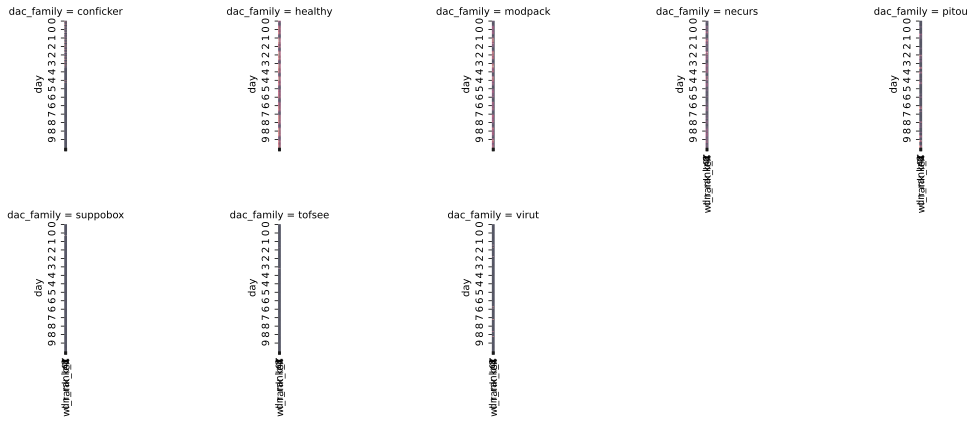

In [8]:

cols = ['qr', 'r', 'nx', 'dn_rank_1', 'wl_rank_le4']

DF_ALL = pd.melt(DF, id_vars=['hourx', 'dac_family'], value_vars=cols, value_name='value')

def draw_heatmap(*args, **kwargs):
    df = kwargs.pop('data')
    sns.heatmap(df.set_index('day')[cols], **kwargs)

fg = sns.FacetGrid(DF, col='dac_family', col_wrap=5, sharex=True, sharey=False)

fg.map_dataframe(draw_heatmap, cbar=False, square = True)
plt.show()

10000
10
0.1
1000
10
0.01
0.1
1


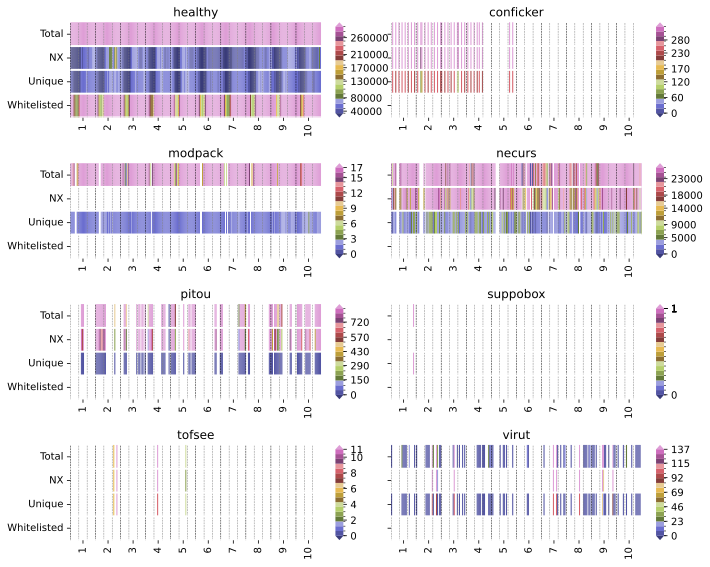

In [150]:


from math import log10
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.ticker import ScalarFormatter


nrows =4
ncols=2
fig, axs = plt.subplots(nrows, ncols, figsize=(10, 8), sharey=True)
axs = cast(np.ndarray, axs)

dac_families = sorted(DF.dac_family.drop_duplicates())
dac_families.remove('healthy')
dac_families.insert(0, 'healthy')

colors = ['orange', 'red', 'blue', 'purple', 'green', 'yellow']
cmap = mcolors.ListedColormap(colors)

cols = ['qr', 'nx', 'u', 'wl_rank_le4']
for idxmw, mw in enumerate(dac_families):
    row = math.floor(idxmw / ncols)
    col = idxmw % ncols
    ax = cast(Axes, axs[row]) if ncols==1 else cast(Axes, axs[row, col])

    DFMW = DF[DF.dac_family == mw].set_index('hourx')[cols]

    num_bins = 20
    bins = pd.cut(np.ceil(DFMW.max(axis=1).div(10)), bins=num_bins - 2, labels=False, precision=0, retbins=True)[1]
    norm = BoundaryNorm(bins, num_bins, clip=False, extend='both')
    ticks = norm.boundaries
    d = 10 ** math.floor(log10(ticks[1]))
    print(d)
    d = d if d > 1 else 1
    ticks = np.ceil(ticks/d) * d
    ticks = [ 0 if t < 0 else t for i, t in enumerate(ticks) if i % 3 == 0 or i == 0 or i > 17 ]
    if all([t == 0 for t in ticks]): ticks[-1]=1

    sns.heatmap(
        DFMW.T,
        annot=False,
        ax=ax,
        square=False,
        cbar_kws={'fraction': 0.08, 'aspect':12, 'ticks': ticks, 'format':ScalarFormatter(useOffset=True)},
        cmap=ListedColormap(sns.color_palette("tab20b", 20)),
        mask=DFMW.T == 0,
        # linewidths=0,#0.00001,
        norm=norm
        # vmax=vmax   
    )
    ax.set_xlabel('')
    ax.set_xticks(list(range(12,240,24)), map(str, range(1,11)))
    
    for day in range(10):
        ax.axvline(day * 24 + 8, c='gray', lw=0.5, ls='dashed')
        ax.axvline(day * 24 + 16, c='gray', lw=0.5, ls='dashed')
        ax.axvline(day * 24, c='black', lw=0.5, ls='dashed')
    
    ax.axhline(1, c='white', lw=2)
    ax.axhline(2, c='white', lw=2)
    ax.axhline(3, c='white', lw=2)
    ax.axhline(4, c='white', lw=2)

    ax.set_title(mw)
    ax.redraw_in_frame()

    ax.set_yticklabels([{
        'qr' : 'Total',
        'nx' : 'NX',
        'u': 'Unique',
        'dn_rank_1': 'Valid',
        'wl_rank_le4': "Whitelisted"
    }[l] for l in cols])
    ax.set_title(mw)
    pass

fig.tight_layout(h_pad = 1, w_pad=0)
fig.savefig('plot_malwares.pdf', bbox_inches="tight")

In [104]:

import matplotlib.cm as cm



nrows =5
ncols=1
fig, axs = plt.subplots(nrows, ncols, figsize=(8, 12), sharey="col")
axs = cast(np.ndarray, axs)

dac_families = sorted(DF.dac_family.drop_duplicates())
dac_families.remove('healthy')
dac_families.insert(0, 'healthy')

DFhere = DF.copy()
# DFhere = DF[DF.dac_family != 'healthy'].copy()
# DFhere = DFhere[DFhere.dac_family != 'necurs'].copy()
vmax = DFhere[['qr', 'nx', 'u', 'dn_rank_1', 'wl_rank_le4']].max().max()
# cols = ['qr', 'nx', 'u', 'dn_rank_1', 'wl_rank_le4']
for idxmw, col in enumerate(['qr', 'nx', 'u', 'dn_rank_1', 'wl_rank_le4']):
    row = math.floor(idxmw / ncols)
    idxcol = idxmw % ncols
    ax = cast(Axes, axs[row]) if ncols==1 else cast(Axes, axs[row, idxcol])

    DFMW = DFhere.pivot(index='hourx', values=col, columns='dac_family')

    bins = pd.cut(np.ceil(DFMW.max(axis=1).div(10)), bins=num_bins - 2, labels=False, precision=0, retbins=True)[1]
    norm = BoundaryNorm(bins, num_bins, clip=False, extend='both')
    ticks = norm.boundaries
    ticks = np.ceil(ticks//10 * 10)
    ticks = [ 0 if t < 0 else t for i, t in enumerate(ticks) if i % 2 == 0 ]

    sns.heatmap(
        DFMW.T,
        annot=False,
        ax=ax,
        square=False,
        cbar_kws={'fraction': 0.05, 'aspect':10, 'ticks': ticks },
        cmap=ListedColormap(sns.color_palette("tab20b", 20)),
        mask=DFMW.T == 0,
        linewidths=0.00001,
        norm=norm
    )
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_xticks(list(range(12,240,24)), map(str, range(1,11)))
    
    
    ax.axhline(1, c='white', lw=2)
    ax.axhline(2, c='white', lw=2)
    ax.axhline(3, c='white', lw=2)
    ax.axhline(4, c='white', lw=2)
    for day in range(24,240,24):
        ax.axvline(day, c='gray', lw=1)

    ax.set_title({
        'qr' : 'Query and responses',
        'nx' : 'NX responses',
        'u': 'Unique domains',
        'dn_rank_1': 'valid domains',
        'wl_rank_le4': "Whitelisted domains"
    }[col])
    ax.redraw_in_frame()
    pass

fig.tight_layout(h_pad = 1, w_pad=0)

